## Imports

In [1]:
import os
import time
import random
import warnings

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
import torch

from ultralytics import YOLO

from tensorflow.keras.models import load_model

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")

In [3]:
print(f"TensorFlow : {tf.__version__}")
print(f"PyTorch    : {torch.__version__}")

print("\nCUDA Available :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))

import ultralytics

print("Ultralytics :", ultralytics.__version__)

TensorFlow : 2.21.0
PyTorch    : 2.9.1+cu130

CUDA Available : True
GPU : NVIDIA GeForce RTX 3060 Ti
Ultralytics : 8.4.100


## Project Paths

In [11]:
import glob

keras_models = glob.glob(os.path.join(MODELS_DIR, "*.keras"))
h5_models = glob.glob(os.path.join(MODELS_DIR, "*.h5"))

all_models = keras_models + h5_models

VGG_MODEL = None
RESNET_MODEL = None
MOBILENET_MODEL = None
EFFICIENTNET_MODEL = None
YOLO_MODEL = None

for model in all_models:

    name = os.path.basename(model).lower()

    if "vgg" in name:
        VGG_MODEL = model

    elif "resnet" in name:
        RESNET_MODEL = model

    elif "mobilenet" in name:
        MOBILENET_MODEL = model

    elif "efficient" in name:
        EFFICIENTNET_MODEL = model

# YOLO Model
pt_models = glob.glob(os.path.join(MODELS_DIR, "*.pt"))

for model in pt_models:

    if "best" in os.path.basename(model).lower():
        YOLO_MODEL = model
        break

## Verify Files

In [14]:
model_paths = {
    "VGG16": VGG_MODEL,
    "ResNet50": RESNET_MODEL,
    "MobileNetV2": MOBILENET_MODEL,
    "EfficientNetB0": EFFICIENTNET_MODEL,
    "YOLOv8": YOLO_MODEL
}

all_found = True

for model_name, model_path in model_paths.items():

    if model_path is None:

        print(f"❌ {model_name:<18} : NOT FOUND")
        all_found = False

    else:

        print(f"✅ {model_name:<18} : {os.path.basename(model_path)}")

if all_found:
    print("All trained models were found successfully.")
else:
    print("One or more models are missing. Please check the models folder.")

✅ VGG16              : vgg16_stage1.keras
✅ ResNet50           : resnet50_stage1.keras
✅ MobileNetV2        : mobilenetv2_stage1.keras
✅ EfficientNetB0     : efficientnetb0_stage1.keras
✅ YOLOv8             : best.pt
All trained models were found successfully.


## Load All Models

In [16]:
vgg_model = load_model(VGG_MODEL)
print("✅ VGG16 Loaded")

resnet_model = load_model(RESNET_MODEL)
print("✅ ResNet50 Loaded")

mobilenet_model = load_model(MOBILENET_MODEL)
print("✅ MobileNetV2 Loaded")

efficientnet_model = load_model(EFFICIENTNET_MODEL)
print("✅ EfficientNetB0 Loaded")

yolo_model = YOLO(YOLO_MODEL)
print("✅ YOLOv8 Loaded")

✅ VGG16 Loaded
✅ ResNet50 Loaded
✅ MobileNetV2 Loaded
✅ EfficientNetB0 Loaded
✅ YOLOv8 Loaded


## Display Model Information

In [17]:
models = {
    "VGG16": vgg_model,
    "ResNet50": resnet_model,
    "MobileNetV2": mobilenet_model,
    "EfficientNetB0": efficientnet_model
}

for name, model in models.items():

    print(f"\n{name}")
    print("-" * 40)
    print(f"Input Shape : {model.input_shape}")
    print(f"Output Shape: {model.output_shape}")
    print(f"Parameters  : {model.count_params():,}")

print("\nYOLOv8")
print("-" * 40)
print(yolo_model.model)


VGG16
----------------------------------------
Input Shape : (None, 224, 224, 3)
Output Shape: (None, 26)
Parameters  : 15,118,426

ResNet50
----------------------------------------
Input Shape : (None, 224, 224, 3)
Output Shape: (None, 26)
Parameters  : 26,234,266

MobileNetV2
----------------------------------------
Input Shape : (None, 224, 224, 3)
Output Shape: (None, 26)
Parameters  : 3,058,010

EfficientNetB0
----------------------------------------
Input Shape : (None, 224, 224, 3)
Output Shape: (None, 26)
Parameters  : 6,031,293

YOLOv8
----------------------------------------
DetectionModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(

## Get Class Names

In [19]:
class_names = sorted(
    [
        folder
        for folder in os.listdir(TEST_DIR)
        if os.path.isdir(os.path.join(TEST_DIR, folder))
    ]
)

NUM_CLASSES = len(class_names)

print("DATASET INFORMATION")
print("Classes:")

for i, cls in enumerate(class_names):
    print(f"{i} : {cls}")

print(f"\nTotal Classes : {NUM_CLASSES}")

DATASET INFORMATION
Classes:
0 : airplane
1 : bed
2 : bench
3 : bicycle
4 : bird
5 : bottle
6 : bowl
7 : bus
8 : cake
9 : car
10 : cat
11 : chair
12 : couch
13 : cow
14 : cup
15 : dog
16 : elephant
17 : horse
18 : motorcycle
19 : person
20 : pizza
21 : potted plant
22 : stop sign
23 : traffic light
24 : train
25 : truck

Total Classes : 26


## Count Test Images

In [22]:
total_images = 0
print("TEST DATASET")
print("=" * 80)

for cls in class_names:

    folder = os.path.join(TEST_DIR, cls)

    count = len(
        [
            f for f in os.listdir(folder)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]
    )

    total_images += count

    print(f"{cls:<20} {count}")

print("-" * 40)
print("Total Test Images :", total_images)

TEST DATASET
airplane             15
bed                  15
bench                15
bicycle              15
bird                 15
bottle               15
bowl                 15
bus                  15
cake                 15
car                  15
cat                  15
chair                15
couch                15
cow                  15
cup                  15
dog                  15
elephant             15
horse                15
motorcycle           15
person               15
pizza                15
potted plant         15
stop sign            15
traffic light        15
train                15
truck                15
----------------------------------------
Total Test Images : 390


## Reusable Data Generator Function

In [ ]:
def create_test_generator(preprocessing_function):
    datagen = ImageDataGenerator(
        preprocessing_function=preprocessing_function
    )
    generator = datagen.flow_from_directory(
        TEST_DIR,
        target_size=(224, 224),
        batch_size=32,
        class_mode="categorical",
        shuffle=False
    )
    return generator

## Create Test Generators

In [24]:
vgg_test = create_test_generator(vgg_preprocess)
resnet_test = create_test_generator(resnet_preprocess)
mobilenet_test = create_test_generator(mobilenet_preprocess)
efficientnet_test = create_test_generator(efficientnet_preprocess)

Found 390 images belonging to 26 classes.
Found 390 images belonging to 26 classes.
Found 390 images belonging to 26 classes.
Found 390 images belonging to 26 classes.


## Verify Dataset

In [26]:
print("VERIFY TEST GENERATORS")
print("=" * 80)

print("VGG16          :", len(vgg_test.filenames))
print("ResNet50       :", len(resnet_test.filenames))
print("MobileNetV2    :", len(mobilenet_test.filenames))
print("EfficientNetB0 :", len(efficientnet_test.filenames))

VERIFY TEST GENERATORS
VGG16          : 390
ResNet50       : 390
MobileNetV2    : 390
EfficientNetB0 : 390


## Classification Evaluation Function

In [27]:
def evaluate_classification_model(model, generator, model_name):
    """
    Evaluate a TensorFlow classification model.
    """

    print("=" * 80)
    print(f"Evaluating {model_name}")
    print("=" * 80)

    # Reset generator
    generator.reset()

    # Inference Time
    start = time.time()

    predictions = model.predict(
        generator,
        verbose=1
    )

    end = time.time()

    inference_time = end - start

    # Predicted Labels
    y_pred = np.argmax(predictions, axis=1)

    # Ground Truth
    y_true = generator.classes

    # Metrics
    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    print(f"Accuracy       : {accuracy:.4f}")
    print(f"Precision      : {precision:.4f}")
    print(f"Recall         : {recall:.4f}")
    print(f"F1 Score       : {f1:.4f}")
    print(f"Inference Time : {inference_time:.2f} sec")

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Inference_Time": inference_time,
        "y_true": y_true,
        "y_pred": y_pred
    }

## Evaluate VGG16

In [28]:
vgg_results = evaluate_classification_model(
    vgg_model,
    vgg_test,
    "VGG16"
)

Evaluating VGG16
13/13 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step
Accuracy       : 0.3308
Precision      : 0.3104
Recall         : 0.3308
F1 Score       : 0.2984
Inference Time : 29.69 sec


## Classification Report (VGG16)

In [30]:
print("VGG16 Classification Report")
print("=" * 80)

print(
    classification_report(
        vgg_results["y_true"],
        vgg_results["y_pred"],
        target_names=class_names,
        zero_division=0
    )
)

VGG16 Classification Report
               precision    recall  f1-score   support

     airplane       0.46      0.73      0.56        15
          bed       0.32      0.60      0.42        15
        bench       0.10      0.27      0.14        15
      bicycle       0.33      0.27      0.30        15
         bird       0.00      0.00      0.00        15
       bottle       0.00      0.00      0.00        15
         bowl       0.27      0.27      0.27        15
          bus       0.22      0.40      0.29        15
         cake       0.07      0.07      0.07        15
          car       0.67      0.67      0.67        15
          cat       0.56      0.67      0.61        15
        chair       0.00      0.00      0.00        15
        couch       0.12      0.07      0.09        15
          cow       0.61      0.73      0.67        15
          cup       0.00      0.00      0.00        15
          dog       1.00      0.13      0.24        15
     elephant       0.73      0.73  

## Confusion Matrix (VGG16)

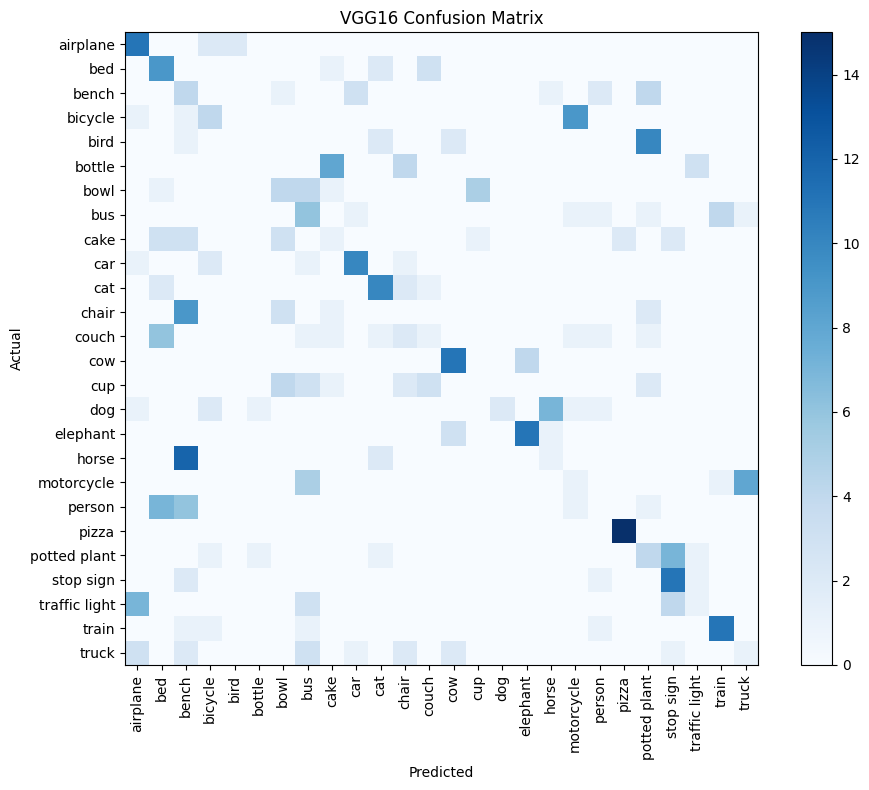

In [31]:
cm = confusion_matrix(
    vgg_results["y_true"],
    vgg_results["y_pred"]
)

plt.figure(figsize=(10, 8))

plt.imshow(cm, cmap="Blues")

plt.title("VGG16 Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.xticks(
    np.arange(NUM_CLASSES),
    class_names,
    rotation=90
)

plt.yticks(
    np.arange(NUM_CLASSES),
    class_names
)

plt.colorbar()

plt.tight_layout()

plt.show()

## Evaluate ResNet50

In [32]:
resnet_results = evaluate_classification_model(
    resnet_model,
    resnet_test,
    "ResNet50"
)

Evaluating ResNet50
13/13 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step
Accuracy       : 0.4641
Precision      : 0.5122
Recall         : 0.4641
F1 Score       : 0.4622
Inference Time : 18.31 sec


## Classification Report (ResNet50)

In [33]:
print(
    classification_report(
        resnet_results["y_true"],
        resnet_results["y_pred"],
        target_names=class_names,
        zero_division=0
    )
)

               precision    recall  f1-score   support

     airplane       0.76      0.87      0.81        15
          bed       0.56      0.67      0.61        15
        bench       0.12      0.27      0.17        15
      bicycle       0.42      0.67      0.51        15
         bird       0.67      0.27      0.38        15
       bottle       0.86      0.80      0.83        15
         bowl       0.36      0.27      0.31        15
          bus       0.67      0.40      0.50        15
         cake       0.06      0.07      0.06        15
          car       0.00      0.00      0.00        15
          cat       0.73      0.73      0.73        15
        chair       0.09      0.13      0.11        15
        couch       0.80      0.27      0.40        15
          cow       0.59      0.87      0.70        15
          cup       0.25      0.07      0.11        15
          dog       0.60      0.20      0.30        15
     elephant       0.92      0.73      0.81        15
        h

## Confusion Matrix (ResNet50)

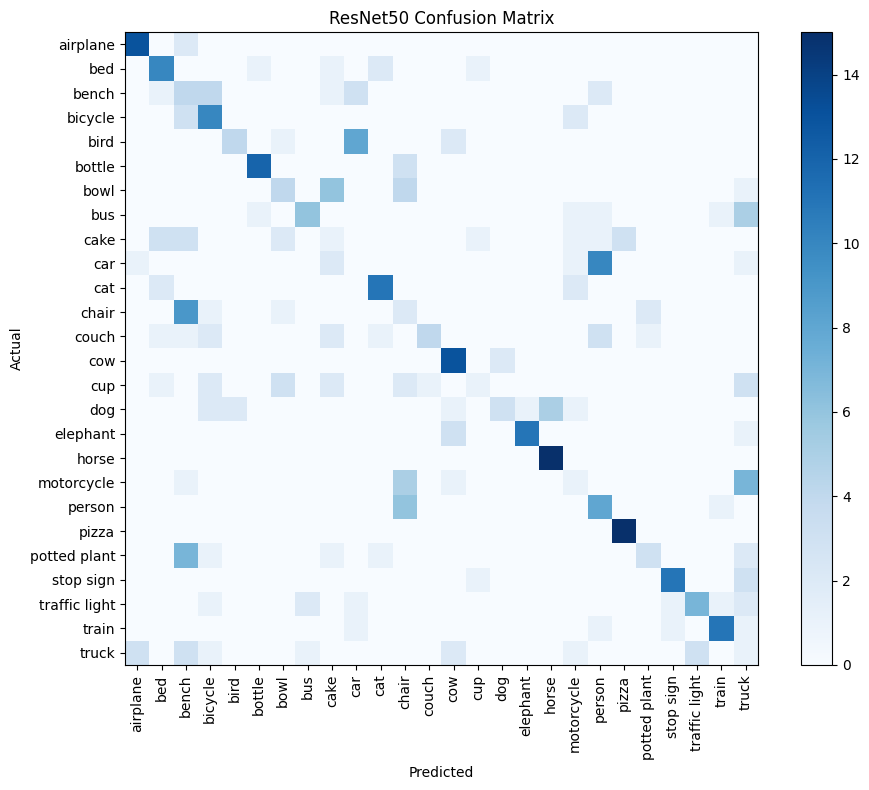

In [34]:
cm = confusion_matrix(
    resnet_results["y_true"],
    resnet_results["y_pred"]
)

plt.figure(figsize=(10, 8))

plt.imshow(cm, cmap="Blues")

plt.title("ResNet50 Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.xticks(
    np.arange(NUM_CLASSES),
    class_names,
    rotation=90
)

plt.yticks(
    np.arange(NUM_CLASSES),
    class_names
)

plt.colorbar()

plt.tight_layout()

plt.show()

## Evaluate MobileNetV2

In [35]:
mobilenet_results = evaluate_classification_model(
    mobilenet_model,
    mobilenet_test,
    "MobileNetV2"
)

Evaluating MobileNetV2
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 608ms/step
Accuracy       : 0.4000
Precision      : 0.3935
Recall         : 0.4000
F1 Score       : 0.3854
Inference Time : 8.78 sec


## MobileNetV2 Classification Report

In [36]:
print("MobileNetV2 Classification Report")
print("=" * 80)

print(
    classification_report(
        mobilenet_results["y_true"],
        mobilenet_results["y_pred"],
        target_names=class_names,
        zero_division=0
    )
)

MobileNetV2 Classification Report
               precision    recall  f1-score   support

     airplane       0.79      0.73      0.76        15
          bed       0.69      0.73      0.71        15
        bench       0.12      0.27      0.16        15
      bicycle       0.82      0.60      0.69        15
         bird       0.29      0.13      0.18        15
       bottle       0.55      0.80      0.65        15
         bowl       0.53      0.53      0.53        15
          bus       0.32      0.40      0.35        15
         cake       0.24      0.33      0.28        15
          car       0.00      0.00      0.00        15
          cat       0.79      0.73      0.76        15
        chair       0.00      0.00      0.00        15
        couch       0.62      0.53      0.57        15
          cow       0.62      0.87      0.72        15
          cup       0.00      0.00      0.00        15
          dog       0.33      0.07      0.11        15
     elephant       0.73      

## MobileNetV2 Confusion Matrix

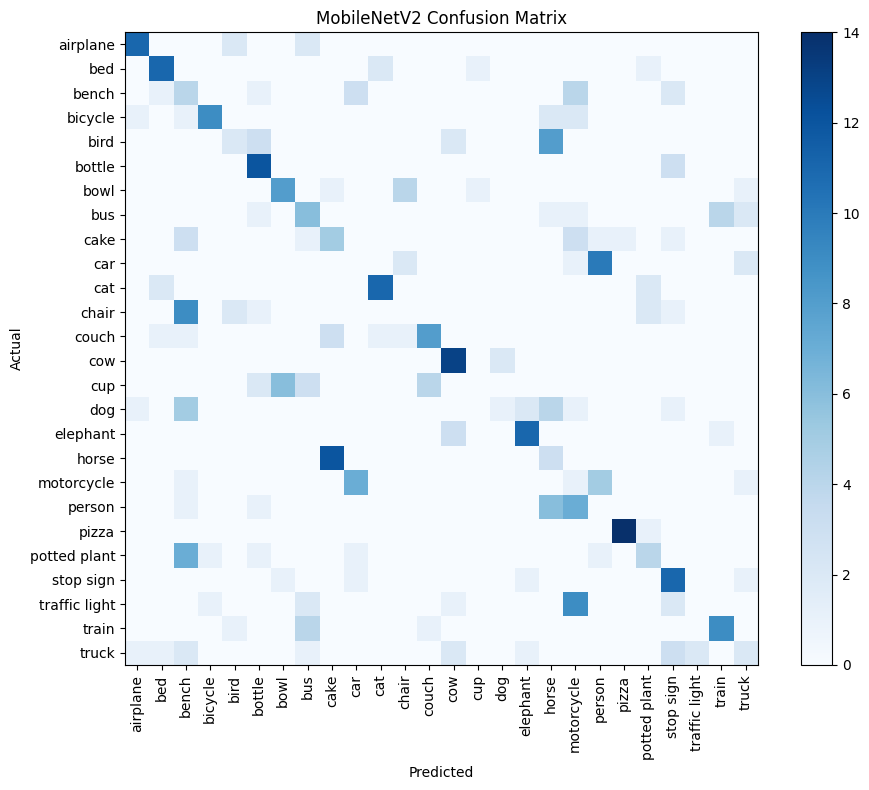

In [37]:
cm = confusion_matrix(
    mobilenet_results["y_true"],
    mobilenet_results["y_pred"]
)

plt.figure(figsize=(10,8))

plt.imshow(cm, cmap="Blues")

plt.title("MobileNetV2 Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.xticks(
    np.arange(NUM_CLASSES),
    class_names,
    rotation=90
)

plt.yticks(
    np.arange(NUM_CLASSES),
    class_names
)

plt.colorbar()

plt.tight_layout()

plt.show()

## Evaluate EfficientNetB0

In [38]:
efficientnet_results = evaluate_classification_model(
    efficientnet_model,
    efficientnet_test,
    "EfficientNetB0"
)

Evaluating EfficientNetB0
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 887ms/step
Accuracy       : 0.4051
Precision      : 0.3581
Recall         : 0.4051
F1 Score       : 0.3676
Inference Time : 13.21 sec


## EfficientNetB0 Classification Report

In [39]:
print("EfficientNetB0 Classification Report")
print("=" * 80)

print(
    classification_report(
        efficientnet_results["y_true"],
        efficientnet_results["y_pred"],
        target_names=class_names,
        zero_division=0
    )
)

EfficientNetB0 Classification Report
               precision    recall  f1-score   support

     airplane       0.45      0.87      0.59        15
          bed       0.57      0.80      0.67        15
        bench       0.00      0.00      0.00        15
      bicycle       0.30      0.60      0.40        15
         bird       0.29      0.13      0.18        15
       bottle       0.85      0.73      0.79        15
         bowl       0.36      0.27      0.31        15
          bus       0.30      0.47      0.37        15
         cake       0.22      0.13      0.17        15
          car       0.00      0.00      0.00        15
          cat       0.67      0.80      0.73        15
        chair       0.00      0.00      0.00        15
        couch       0.33      0.13      0.19        15
          cow       0.75      0.60      0.67        15
          cup       0.33      0.27      0.30        15
          dog       0.18      0.13      0.15        15
     elephant       0.88   

## EfficientNetB0 Confusion Matrix

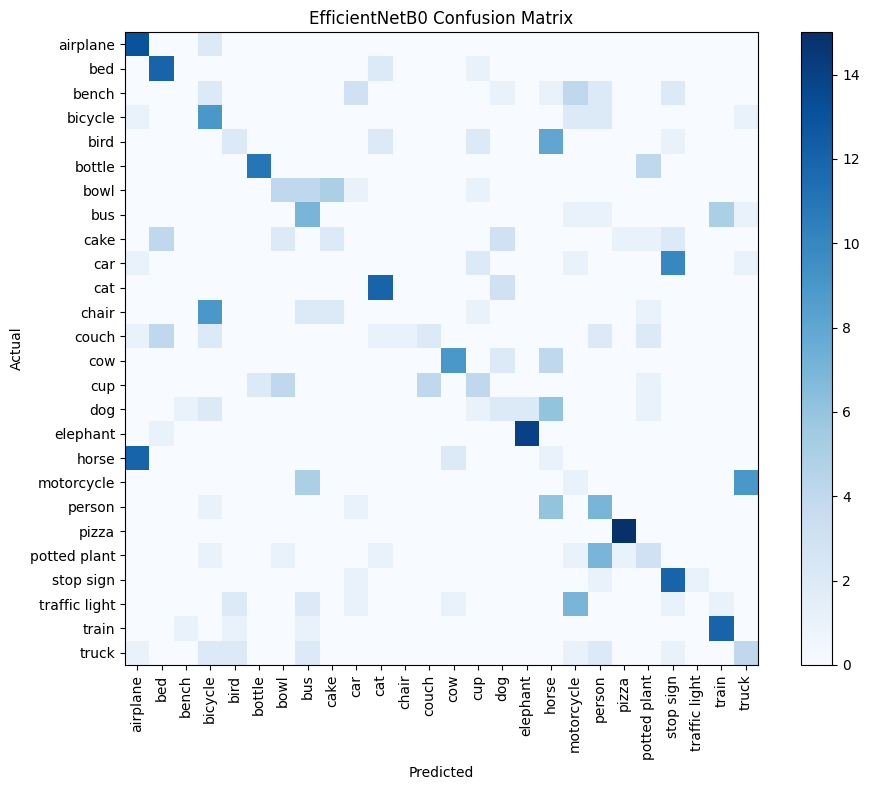

In [40]:
cm = confusion_matrix(
    efficientnet_results["y_true"],
    efficientnet_results["y_pred"]
)

plt.figure(figsize=(10,8))

plt.imshow(cm, cmap="Blues")

plt.title("EfficientNetB0 Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.xticks(
    np.arange(NUM_CLASSES),
    class_names,
    rotation=90
)

plt.yticks(
    np.arange(NUM_CLASSES),
    class_names
)

plt.colorbar()

plt.tight_layout()

plt.show()

## Classification Comparison DataFrame

In [41]:
classification_results = pd.DataFrame([
    {
        "Model": vgg_results["Model"],
        "Accuracy": vgg_results["Accuracy"],
        "Precision": vgg_results["Precision"],
        "Recall": vgg_results["Recall"],
        "F1 Score": vgg_results["F1"],
        "Inference Time (s)": vgg_results["Inference_Time"]
    },
    {
        "Model": resnet_results["Model"],
        "Accuracy": resnet_results["Accuracy"],
        "Precision": resnet_results["Precision"],
        "Recall": resnet_results["Recall"],
        "F1 Score": resnet_results["F1"],
        "Inference Time (s)": resnet_results["Inference_Time"]
    },
    {
        "Model": mobilenet_results["Model"],
        "Accuracy": mobilenet_results["Accuracy"],
        "Precision": mobilenet_results["Precision"],
        "Recall": mobilenet_results["Recall"],
        "F1 Score": mobilenet_results["F1"],
        "Inference Time (s)": mobilenet_results["Inference_Time"]
    },
    {
        "Model": efficientnet_results["Model"],
        "Accuracy": efficientnet_results["Accuracy"],
        "Precision": efficientnet_results["Precision"],
        "Recall": efficientnet_results["Recall"],
        "F1 Score": efficientnet_results["F1"],
        "Inference Time (s)": efficientnet_results["Inference_Time"]
    }
])

classification_results

,Model,Accuracy,Precision,Recall,F1 Score,Inference Time (s)
0,VGG16,0.330769,0.310407,0.330769,0.298445,29.691429
1,ResNet50,0.464103,0.512173,0.464103,0.462199,18.314537
2,MobileNetV2,0.400000,0.393480,0.400000,0.385354,8.776567
3,EfficientNetB0,0.405128,0.358123,0.405128,0.367562,13.212709


## Save Classification Results

In [42]:
classification_results.to_csv(
    "classification_model_comparison.csv",
    index=False
)

print("Classification comparison saved successfully.")

Classification comparison saved successfully.


## Best Classification Model

In [43]:
best_model = classification_results.loc[
    classification_results["Accuracy"].idxmax()
]

print("=" * 80)
print("BEST CLASSIFICATION MODEL")
print("=" * 80)

print(best_model)

BEST CLASSIFICATION MODEL
Model                  ResNet50
Accuracy               0.464103
Precision              0.512173
Recall                 0.464103
F1 Score               0.462199
Inference Time (s)    18.314537
Name: 1, dtype: object


## YOLO Training path

In [45]:
import glob

RUNS_DIR = os.path.join(PROJECT_DIR, "notebooks/runs/runs")

detect_runs = sorted(
    glob.glob(os.path.join(RUNS_DIR, "*")),
    key=os.path.getmtime
)

LATEST_RUN = detect_runs[-1]

print("=" * 80)
print("Latest YOLO Run")
print("=" * 80)
print(LATEST_RUN)

Latest YOLO Run
..\notebooks/runs/runs\SmartVision_YOLOv8-4


In [46]:
results_csv = os.path.join(
    LATEST_RUN,
    "results.csv"
)

if os.path.exists(results_csv):

    yolo_history = pd.read_csv(results_csv)

    print(yolo_history.tail())

else:

    print("results.csv not found.")

    epoch     time  train/box_loss  train/cls_loss  train/dfl_loss  \
45     46  232.671         0.91380         1.34634         1.48903   
46     47  236.979         0.88500         1.35197         1.44467   
47     48  241.214         0.86436         1.33040         1.45185   
48     49  245.440         0.83790         1.27675         1.43480   
49     50  249.547         0.83969         1.27850         1.43573   

    metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  \
45               0.67519            0.49038           0.55292   
46               0.63275            0.49912           0.56349   
47               0.78235            0.45416           0.57121   
48               0.78413            0.45542           0.57742   
49               0.71641            0.49890           0.58365   

    metrics/mAP50-95(B)  val/box_loss  val/cls_loss  val/dfl_loss    lr/pg0  \
45              0.32854       1.71350       2.00444       2.54550  0.000109   
46              0.33214       

## YOLO Metrics

In [47]:
last_epoch = yolo_history.iloc[-1]

yolo_precision = last_epoch["metrics/precision(B)"]
yolo_recall = last_epoch["metrics/recall(B)"]
yolo_map50 = last_epoch["metrics/mAP50(B)"]
yolo_map5095 = last_epoch["metrics/mAP50-95(B)"]

print("=" * 80)
print("YOLO FINAL METRICS")
print("=" * 80)

print(f"Precision : {yolo_precision:.4f}")
print(f"Recall    : {yolo_recall:.4f}")
print(f"mAP50     : {yolo_map50:.4f}")
print(f"mAP50-95  : {yolo_map5095:.4f}")

YOLO FINAL METRICS
Precision : 0.7164
Recall    : 0.4989
mAP50     : 0.5837
mAP50-95  : 0.3377


## YOLO Inference Speed

In [49]:
import time

test_images = glob.glob(
    os.path.join(
        PROJECT_DIR,"smartvision_dataset/detection/test/images",
        "*.jpg")
)

sample_image = random.choice(test_images)

start = time.time()

prediction = yolo_model.predict(
    source=sample_image,
    verbose=False
)

end = time.time()

yolo_inference = end - start

print(f"Inference Time : {yolo_inference:.4f} seconds")

Inference Time : 6.1904 seconds


## Display Detection

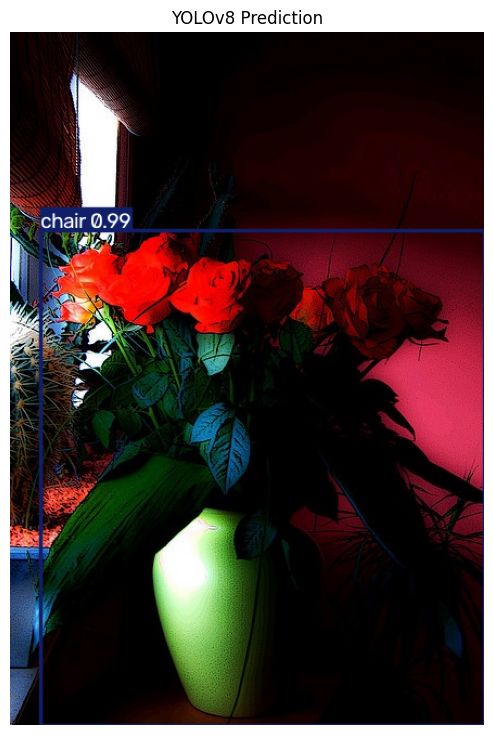

In [55]:
result = prediction[0]

annotated = result.plot()

plt.figure(figsize=(10,9))

plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))

plt.axis("off")

plt.title("YOLOv8 Prediction")

plt.show()

In [56]:
boxes = result.boxes

print("=" * 80)
print("Detected Objects")
print("=" * 80)

if len(boxes) == 0:

    print("No objects detected.")

else:

    for box in boxes:

        cls = int(box.cls)

        conf = float(box.conf)

        print(
            f"{yolo_model.names[cls]:20} {conf:.3f}"
        )

Detected Objects
chair                0.989


## Display Training Curve

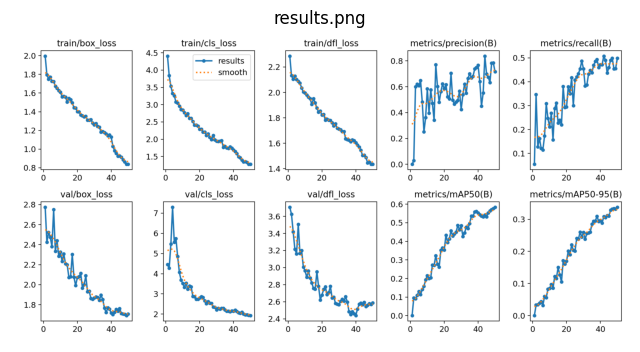

PR_curve.png not found.
F1_curve.png not found.
P_curve.png not found.
R_curve.png not found.


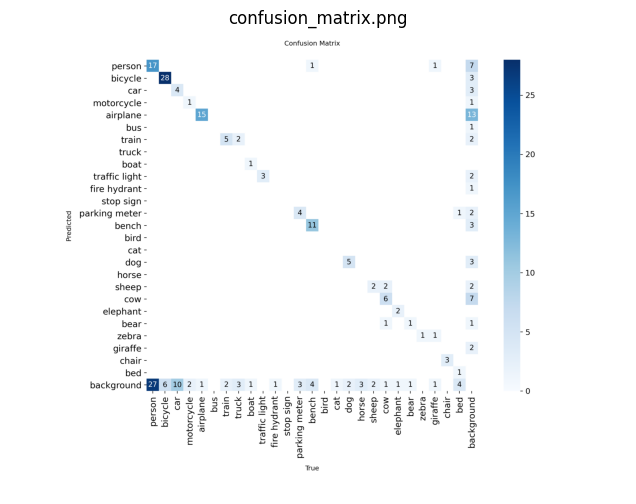

In [57]:
curve_files = [
    "results.png",
    "PR_curve.png",
    "F1_curve.png",
    "P_curve.png",
    "R_curve.png",
    "confusion_matrix.png"
]

for file in curve_files:

    path = os.path.join(LATEST_RUN, file)

    if os.path.exists(path):

        image = cv2.imread(path)

        plt.figure(figsize=(8,6))

        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

        plt.title(file)

        plt.axis("off")

        plt.show()

    else:

        print(f"{file} not found.")

## YOLO Results Dictionary

In [58]:
yolo_results = {
    "Model": "YOLOv8",
    "Accuracy": np.nan,
    "Precision": yolo_precision,
    "Recall": yolo_recall,
    "F1 Score": np.nan,
    "mAP50": yolo_map50,
    "mAP50-95": yolo_map5095,
    "Inference Time (s)": yolo_inference
}

pd.DataFrame([yolo_results])

,Model,Accuracy,Precision,Recall,F1 Score,mAP50,mAP50-95,Inference Time (s)
0,YOLOv8,NaN,0.71641,0.4989,NaN,0.58365,0.33767,6.190392


## Final Comparison

In [59]:
final_results = classification_results.copy()

yolo_row = pd.DataFrame([{
    "Model": "YOLOv8",
    "Accuracy": np.nan,
    "Precision": yolo_precision,
    "Recall": yolo_recall,
    "F1 Score": np.nan,
    "Inference Time (s)": yolo_inference
}])

final_results = pd.concat(
    [final_results, yolo_row],
    ignore_index=True
)

final_results

,Model,Accuracy,Precision,Recall,F1 Score,Inference Time (s)
0,VGG16,0.330769,0.310407,0.330769,0.298445,29.691429
1,ResNet50,0.464103,0.512173,0.464103,0.462199,18.314537
2,MobileNetV2,0.400000,0.393480,0.400000,0.385354,8.776567
3,EfficientNetB0,0.405128,0.358123,0.405128,0.367562,13.212709
4,YOLOv8,NaN,0.716410,0.498900,NaN,6.190392


## Save Final Results

In [60]:
final_results.to_csv(
    "SmartVision_Model_Comparison.csv",
    index=False
)

print("Final comparison saved successfully.")

Final comparison saved successfully.


## Accuracy Comparison

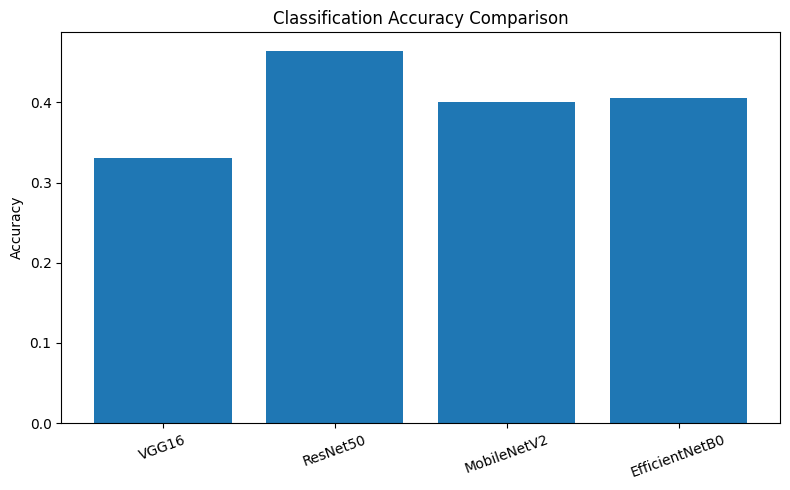

In [61]:
plt.figure(figsize=(8,5))

classification_only = final_results.dropna(subset=["Accuracy"])

plt.bar(
    classification_only["Model"],
    classification_only["Accuracy"]
)

plt.title("Classification Accuracy Comparison")

plt.ylabel("Accuracy")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

## Precision Comparison

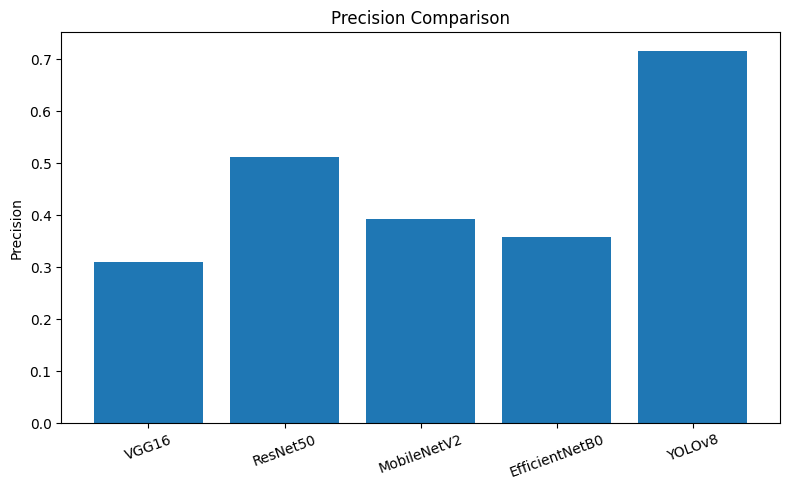

In [62]:
plt.figure(figsize=(8,5))

plt.bar(
    final_results["Model"],
    final_results["Precision"]
)

plt.title("Precision Comparison")

plt.ylabel("Precision")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

## Recall Comparison

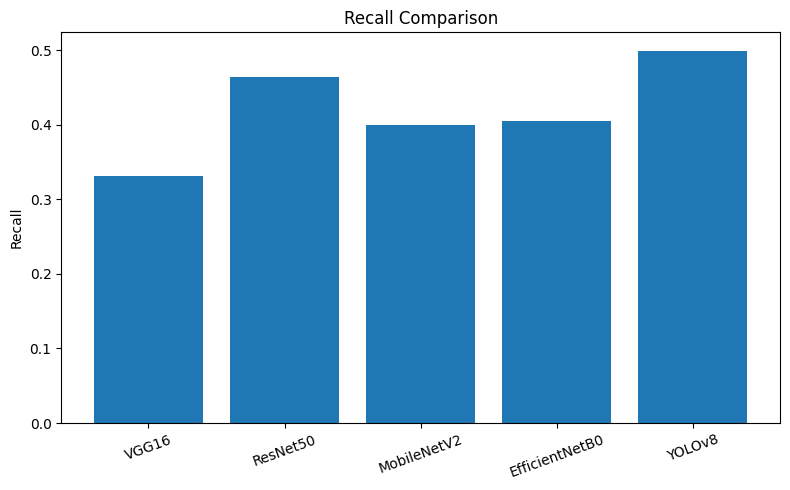

In [63]:
plt.figure(figsize=(8,5))

plt.bar(
    final_results["Model"],
    final_results["Recall"]
)

plt.title("Recall Comparison")

plt.ylabel("Recall")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

## F1 Score Comparison

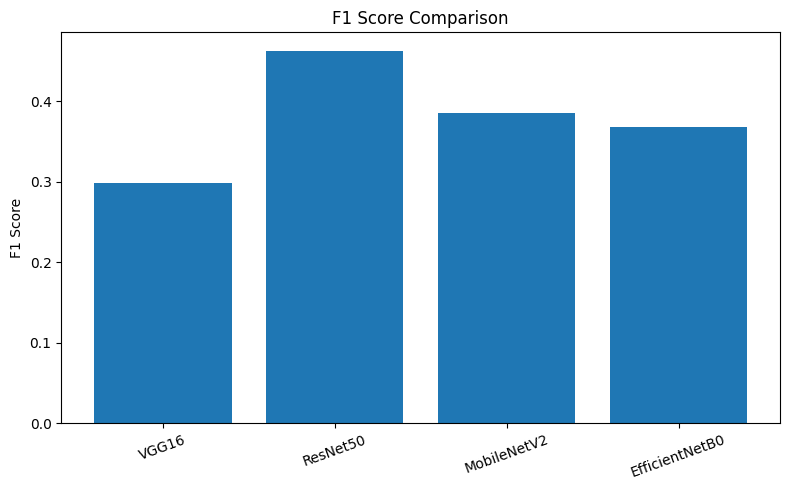

In [64]:
plt.figure(figsize=(8,5))

classification_only = final_results.dropna(subset=["F1 Score"])

plt.bar(
    classification_only["Model"],
    classification_only["F1 Score"]
)

plt.title("F1 Score Comparison")

plt.ylabel("F1 Score")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

## Inference Time Comparison

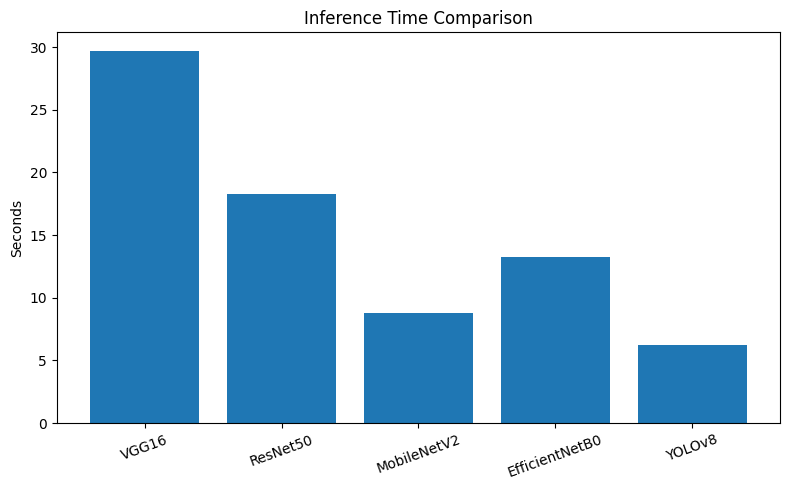

In [65]:
plt.figure(figsize=(8,5))

plt.bar(
    final_results["Model"],
    final_results["Inference Time (s)"]
)

plt.title("Inference Time Comparison")

plt.ylabel("Seconds")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

## Display Best Models

In [ ]:
print("BEST MODEL SUMMARY")
print("=" * 80)

best_accuracy = classification_only.loc[
    classification_only["Accuracy"].idxmax()
]

best_precision = final_results.loc[
    final_results["Precision"].idxmax()
]

best_recall = final_results.loc[
    final_results["Recall"].idxmax()
]

fastest = final_results.loc[
    final_results["Inference Time (s)"].idxmin()
]

print(f"Best Accuracy      : {best_accuracy['Model']}")
print(f"Best Precision     : {best_precision['Model']}")
print(f"Best Recall        : {best_recall['Model']}")
print(f"Fastest Model      : {fastest['Model']}")

BEST MODEL SUMMARY
Best Accuracy      : ResNet50
Best Precision     : YOLOv8
Best Recall        : YOLOv8
Fastest Model      : YOLOv8


## Sample Predictions from Classification

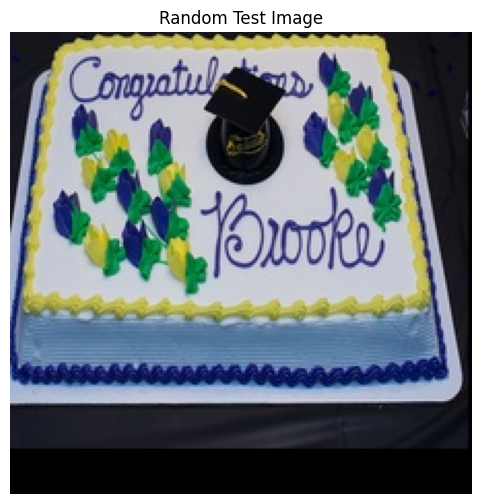

In [67]:
sample_image = random.choice(vgg_test.filepaths)

image = tf.keras.preprocessing.image.load_img(
    sample_image,
    target_size=(224,224)
)

plt.figure(figsize=(6,6))
plt.imshow(image)
plt.axis("off")
plt.title("Random Test Image")
plt.show()

## Predict Using All Classification

In [68]:
img = tf.keras.preprocessing.image.img_to_array(image)

predictions = {}

model_info = [
    ("VGG16", vgg_model, vgg_preprocess),
    ("ResNet50", resnet_model, resnet_preprocess),
    ("MobileNetV2", mobilenet_model, mobilenet_preprocess),
    ("EfficientNetB0", efficientnet_model, efficientnet_preprocess)
]

for name, model, preprocess in model_info:

    x = np.expand_dims(img.copy(), axis=0)
    x = preprocess(x)

    pred = model.predict(x, verbose=0)

    predictions[name] = class_names[np.argmax(pred)]

print("=" * 80)
print("CLASSIFICATION PREDICTIONS")
print("=" * 80)

for model, pred in predictions.items():
    print(f"{model:<20} {pred}")

CLASSIFICATION PREDICTIONS
VGG16                stop sign
ResNet50             cup
MobileNetV2          stop sign
EfficientNetB0       stop sign


# YOLO Prediction on Same Image

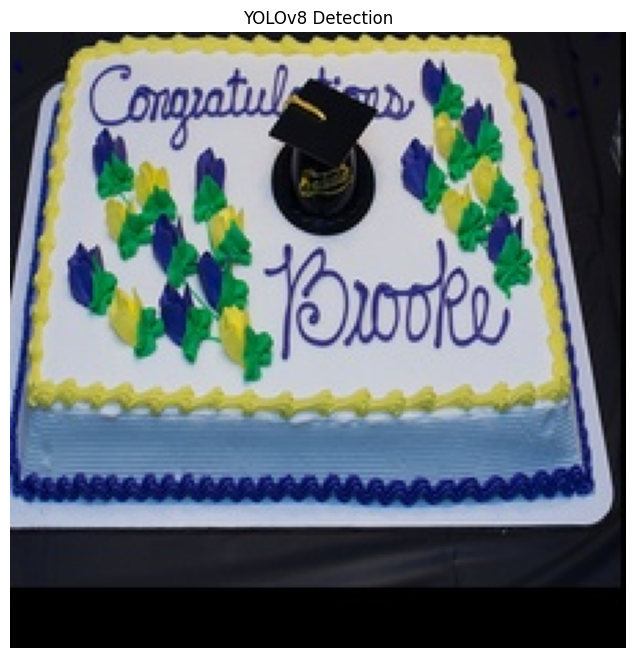

In [69]:
prediction = yolo_model.predict(
    source=sample_image,
    verbose=False
)

result = prediction[0]

annotated = result.plot()

plt.figure(figsize=(8,8))

plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))

plt.axis("off")

plt.title("YOLOv8 Detection")

plt.show()

## Final Project Summary

In [70]:
print("SMARTVISION AI PROJECT SUMMARY")
print("=" * 80)

print("""
Models Developed
----------------
1. VGG16
2. ResNet50
3. MobileNetV2
4. EfficientNetB0
5. YOLOv8

Evaluation Completed
--------------------
✓ Accuracy
✓ Precision
✓ Recall
✓ F1 Score
✓ Confusion Matrix
✓ Classification Reports
✓ YOLO Detection Metrics
✓ Inference Time Comparison
✓ Sample Predictions

Project Status
--------------
✓ Completed Successfully
""")

SMARTVISION AI PROJECT SUMMARY

Models Developed
----------------
1. VGG16
2. ResNet50
3. MobileNetV2
4. EfficientNetB0
5. YOLOv8

Evaluation Completed
--------------------
✓ Accuracy
✓ Precision
✓ Recall
✓ F1 Score
✓ Confusion Matrix
✓ Classification Reports
✓ YOLO Detection Metrics
✓ Inference Time Comparison
✓ Sample Predictions

Project Status
--------------
✓ Completed Successfully

